<a href="https://colab.research.google.com/github/lcorn132/TH_DeepLearning/blob/main/Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CNN (CONVOLUTIONAL NEURAL NETWORK)


##1. Giới Thiệu
Convolutional Artificial Neural Network (Convnets hoặc CNN) là một mô hình nổi tiếng trong lĩnh vực thị giác máy tính. Kiến trúc này dùng nhận dạng đối tượng trong ảnh hoặc video.

Nguyên lý hoạt động CNN:
- Một ảnh được đưa vào CNN gọi là ảnh đầu vào
- Ảnh đầu vào sẽ được các phép toán chập xử lý
- Đầu ra là nhãn được CNN dự báo

##2. Cài Đặt CNN

#####2.1 Nạp thư viện

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

#####2.2 Đọc dũ liệu MNIST

In [3]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [4]:
num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0],28,28,1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0],28,28,1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


#####2.3 Trực quan hóa 10 ảnh đầu tiên

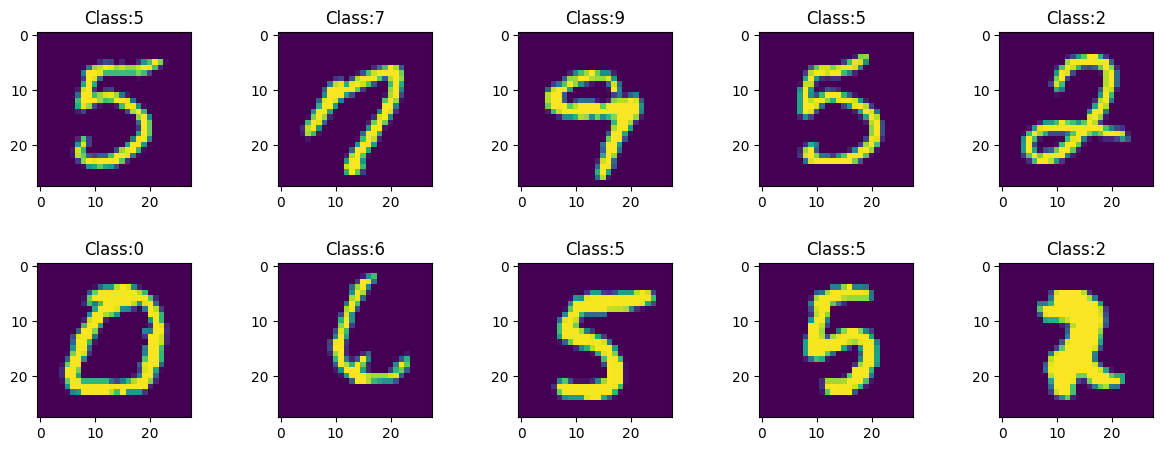

In [5]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

#####2.4 Chuyển giá trị nhãn thành one-hot encoding

In [6]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_train.shape, y_test.shape)

(19999, 10) (9999, 10)


######2.5 Xây dựng mô hình

In [7]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#####2.6 Huấn luyện mô hình CNN

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.8687 - loss: 0.4526 - val_accuracy: 0.9570 - val_loss: 0.1474
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.9664 - loss: 0.1090 - val_accuracy: 0.9670 - val_loss: 0.1070
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9786 - loss: 0.0697 - val_accuracy: 0.9720 - val_loss: 0.0857
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9829 - loss: 0.0511 - val_accuracy: 0.9780 - val_loss: 0.0758
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9825 - val_loss: 0.0629
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9810 - val_loss: 0.0765
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.9928 - loss: 0.0237 - val_accuracy: 0.9855 - val_loss: 0.0652
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.9937 - loss: 0

#####2.7 Đánh giá mô hình CNN

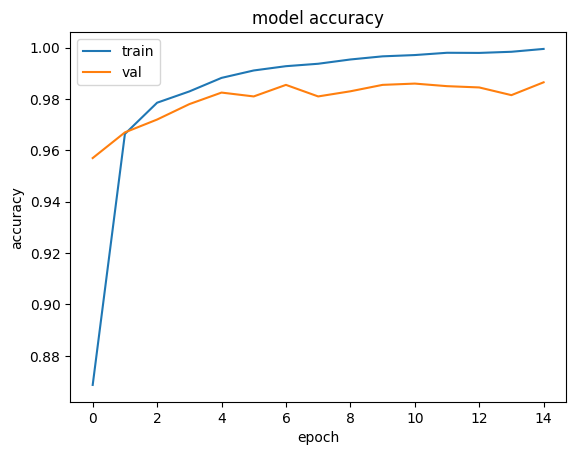

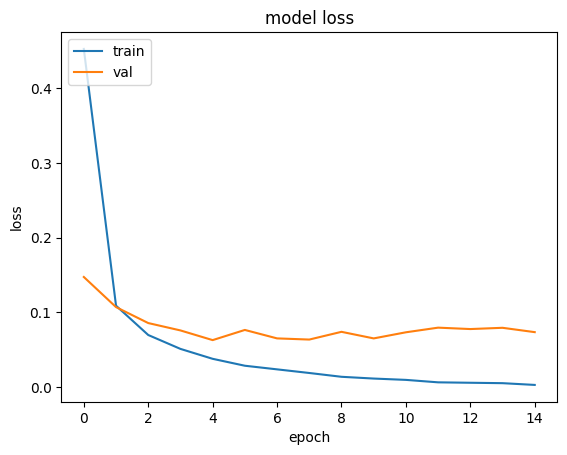

In [10]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#####2.8 Đánh giá mô hình CNN thử nghiệm trên tập test

In [11]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 10ms/step - accuracy: 0.9836 - loss: 0.0580
Test loss: 0.05795084685087204
Test accuracy: 0.9835983514785767


#####2.9. Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
[[6.4475398e-07 3.0162965e-08 9.9999940e-01 1.5998475e-09 4.9582100e-19
  2.4515215e-15 2.6438072e-09 2.5671308e-18 4.1648200e-08 1.9559067e-19]]
2 2


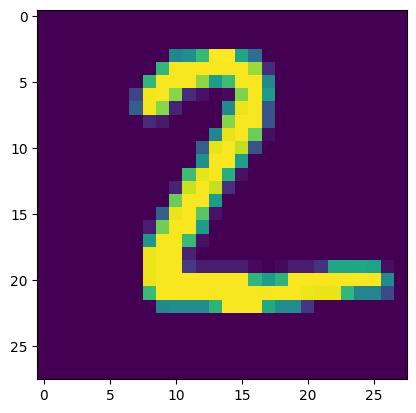

In [12]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

#####2.10. Lưu tham số mô hình CNN

In [15]:
model.save_weights('cnn.weights.h5')

#####2.11. Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[7.8916784e-09 9.9997926e-01 1.5395527e-06 1.7965091e-09 1.4338274e-05
  5.7421085e-10 2.9106491e-07 1.4566534e-06 3.1339164e-06 8.9348293e-11]]
1 1


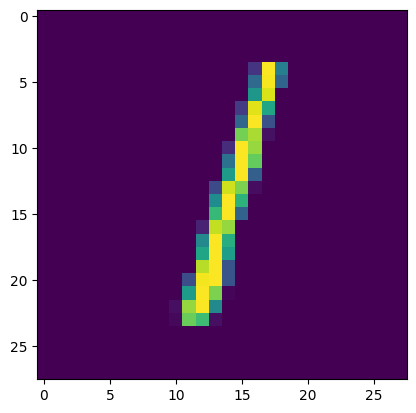

In [18]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu')) # Added the missing Dense layer
model.add(Dense(units=num_classes, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

##3 Bài Tập

####1. Viết chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, utils
from tensorflow.keras.models import load_model

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
print("--- Bước 1: Đọc dữ liệu ---")
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Chuẩn hóa dữ liệu ảnh về khoảng [0, 1] để mô hình hội tụ nhanh hơn
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}\n")

--- Bước 1: Đọc dữ liệu ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Kích thước tập train: (50000, 32, 32, 3)
Kích thước tập test: (10000, 32, 32, 3)



--- Bước 2: Trực quan hóa dữ liệu ---


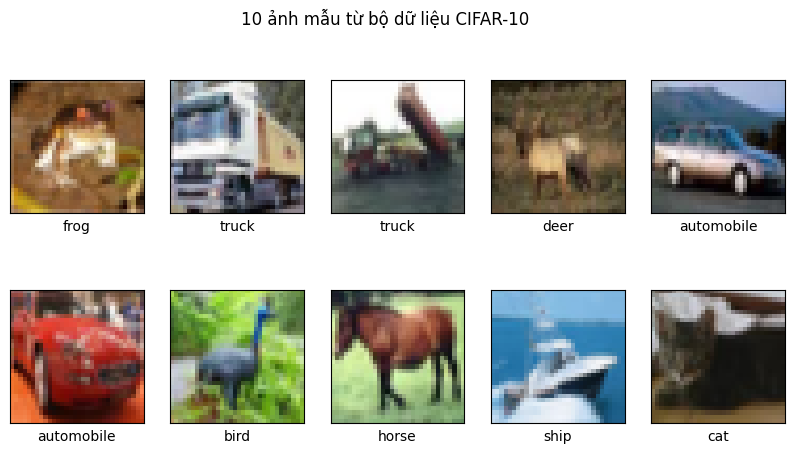

In [3]:
# ==========================================
# 2. TRỰC QUAN HÓA DỮ LIỆU
# ==========================================
print("--- Bước 2: Trực quan hóa dữ liệu ---")
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle("10 ảnh mẫu từ bộ dữ liệu CIFAR-10")
plt.show()

In [4]:
# ==========================================
# 3. CHUYỂN GIÁ TRỊ NHÃN THÀNH ONE-HOT ENCODING
# ==========================================
print("--- Bước 3: Chuyển nhãn thành One-hot encoding ---")
Y_train = utils.to_categorical(y_train, 10)
Y_test = utils.to_categorical(y_test, 10)

print(f"Nhãn ban đầu của ảnh đầu tiên: {y_train[0]}")
print(f"Nhãn sau khi chuyển sang One-hot: {Y_train[0]}\n")

--- Bước 3: Chuyển nhãn thành One-hot encoding ---
Nhãn ban đầu của ảnh đầu tiên: [6]
Nhãn sau khi chuyển sang One-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]



In [6]:
print("--- Bước 4: Xây dựng mô hình CNN ---")
model = models.Sequential([
    # Khai báo kích thước đầu vào bằng lớp Input chuyên dụng theo khuyến nghị
    layers.Input(shape=(32, 32, 3)),

    # Khối Convolution 1 (Bỏ tham số input_shape ở đây đi)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Khối Convolution 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Khối Fully Connected (Dense)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Biên dịch mô hình
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

--- Bước 4: Xây dựng mô hình CNN ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

In [7]:
# ==========================================
# 5. HUẤN LUYỆN MÔ HÌNH CNN
# ==========================================
from tensorflow.keras.callbacks import ModelCheckpoint

# Cấu hình bộ tự động lưu mô hình tối ưu nhất
checkpoint_callback = ModelCheckpoint(
    filepath='cifar10_cnn_best_model.keras', # Tên file muốn lưu
    monitor='val_loss',                      # Theo dõi hàm loss trên tập validation
    save_best_only=True,                     # CHỈ LƯU khi val_loss giảm (tốt hơn mức cũ)
    mode='min',                              # Tìm giá trị loss nhỏ nhất
    verbose=1                                # In thông báo mỗi khi lưu
)

# Thêm callback vào quá trình huấn luyện ở Bước 5
history = model.fit(X_train, Y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.1,
                    callbacks=[checkpoint_callback]) # Kích hoạt bộ tự động lưu

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3920 - loss: 1.8894
Epoch 1: val_loss improved from None to 1.04735, saving model to cifar10_cnn_best_model.keras

Epoch 1: finished saving model to cifar10_cnn_best_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.4814 - loss: 1.5202 - val_accuracy: 0.6336 - val_loss: 1.0473
Epoch 2/15
698/704 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6150 - loss: 1.0819
Epoch 2: val_loss improved from 1.04735 to 0.89516, saving model to cifar10_cnn_best_model.keras

Epoch 2: finished saving model to cifar10_cnn_best_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6314 - loss: 1.0450 - val_accuracy: 0.6900 - val_loss: 0.8952
Epoch 3/15
701/704 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6763 - loss: 0.9178
Epoch 3: val_loss improved from 0.89516 to 0.79307, saving model to cifar10_cnn_best_model.keras

Epoch 3: finished saving model to cifar10_cnn_best_model.keras
704/704 ━━━━━━━━━━━━━━━━━


--- Bước 6: Đánh giá mô hình CNN qua lịch sử huấn luyện ---


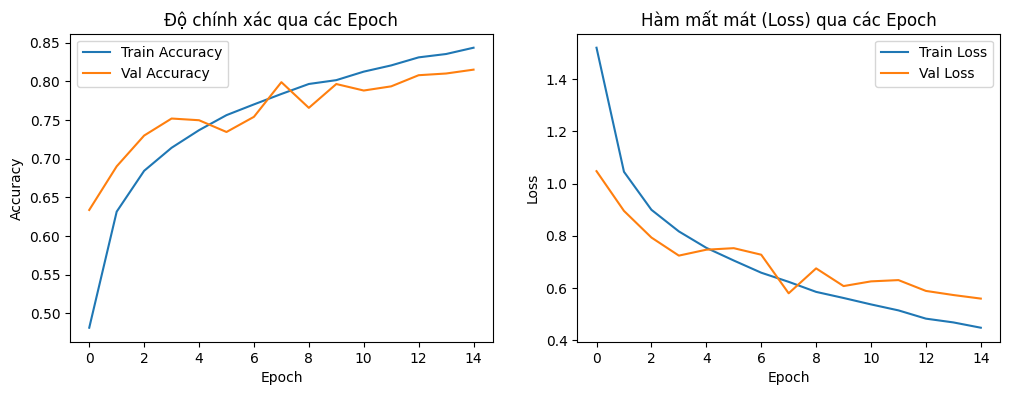

In [8]:
# ==========================================
# 6. ĐÁNH GIÁ MÔ HÌNH CNN (Qua đồ thị huấn luyện)
# ==========================================
print("\n--- Bước 6: Đánh giá mô hình CNN qua lịch sử huấn luyện ---")
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Độ chính xác qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Hàm mất mát (Loss) qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# ==========================================
# 7. ĐÁNH GIÁ MÔ HÌNH CNN THỬ NGHIỆM TRÊN TẬP TEST
# ==========================================
print("\n--- Bước 7: Đánh giá mô hình trên tập Test ---")
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=2)
print(f"Độ chính xác trên tập Test: {test_acc*100:.2f}%\n")


--- Bước 7: Đánh giá mô hình trên tập Test ---
313/313 - 2s - 8ms/step - accuracy: 0.8046 - loss: 0.5888
Độ chính xác trên tập Test: 80.46%



--- Bước 8: Dự báo nhãn cho một số ảnh ngẫu nhiên từ tập Test ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


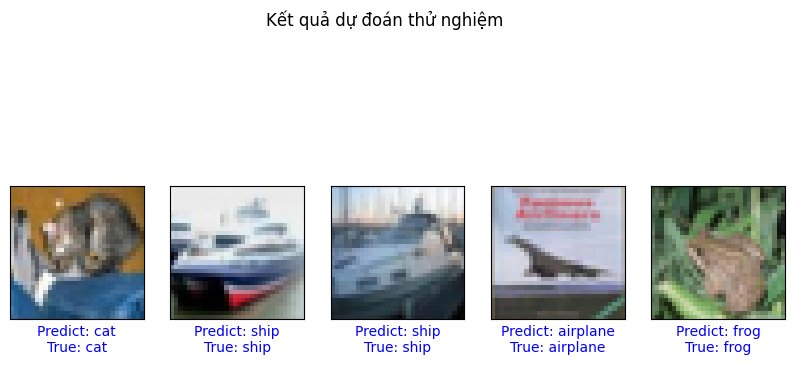

In [10]:
# ==========================================
# 8. DỰ BÁO NHÃN CHO ẢNH SỬ DỤNG CNN
# ==========================================
print("--- Bước 8: Dự báo nhãn cho một số ảnh ngẫu nhiên từ tập Test ---")
predictions = model.predict(X_test)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_test[i])

    # Lấy chỉ số nhãn có xác suất cao nhất
    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(Y_test[i])

    # Màu xanh nếu đoán đúng, màu đỏ nếu đoán sai
    color = 'blue' if pred_label == true_label else 'red'
    plt.xlabel(f"Predict: {class_names[pred_label]}\nTrue: {class_names[true_label]}", color=color)
plt.suptitle("Kết quả dự đoán thử nghiệm")
plt.show()

In [11]:
# ==========================================
# 9. LƯU THAM SỐ MÔ HÌNH CNN
# ==========================================
print("\n--- Bước 9: Lưu mô hình và tham số ---")
model.save('cifar10_cnn_model.keras')
print("Đã lưu mô hình thành công vào file 'cifar10_cnn_model.keras'\n")


--- Bước 9: Lưu mô hình và tham số ---
Đã lưu mô hình thành công vào file 'cifar10_cnn_model.keras'



In [12]:
# ==========================================
# 10. NẠP LẠI MÔ HÌNH VÀ THAM SỐ
# ==========================================
print("--- Bước 10: Nạp lại mô hình và tham số ---")
saved_model = load_model('cifar10_cnn_model.keras')
print("Đã nạp lại mô hình thành công.")

# Kiểm tra nhanh mô hình vừa nạp lại bằng cách đánh giá trên tập test
loaded_loss, loaded_acc = saved_model.evaluate(X_test, Y_test, verbose=0)
print(f"Độ chính xác của mô hình vừa nạp lại: {loaded_acc*100:.2f}%")

--- Bước 10: Nạp lại mô hình và tham số ---
Đã nạp lại mô hình thành công.
Độ chính xác của mô hình vừa nạp lại: 80.46%


Nạp mô hình thành công! Hãy tải ảnh của bạn lên phía dưới.


Saving maybay.jpg to maybay.jpg


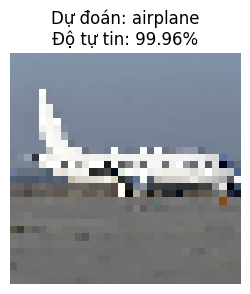

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files # Chỉ dùng được trên Google Colab

# 1. Định nghĩa lại danh sách nhãn chuẩn của CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Nạp lại mô hình tốt nhất đã lưu
try:
    my_model = load_model('cifar10_cnn_best_model.keras')
    print("Nạp mô hình thành công! Hãy tải ảnh của bạn lên phía dưới.")
except:
    print("Không tìm thấy file mô hình. Hãy chắc chắn bạn đã chạy Bước 5 hoặc Bước 9.")

# 3. Mở hộp thoại để bạn chọn file ảnh từ máy tính tải lên
uploaded = files.upload()

for filename in uploaded.keys():
    # 4. Đọc và tiền xử lý ảnh tải lên
    # Ép kích thước ảnh về đúng 32x32 giống dữ liệu huấn luyện
    img_path = filename
    img = image.load_img(img_path, target_size=(32, 32))

    # Chuyển ảnh thành mảng numpy và chuẩn hóa về khoảng [0, 1]
    img_array = image.img_to_array(img)
    img_array = img_array.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Thêm chiều batch size (1, 32, 32, 3)

    # 5. Dự đoán bằng mô hình CNN
    predictions = my_model.predict(img_array, verbose=0)
    score = np.max(predictions) # Độ tự tin cao nhất
    class_idx = np.argmax(predictions) # Chỉ số của nhãn đoán được

    # 6. Hiển thị kết quả trực quan
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Dự đoán: {class_names[class_idx]}\nĐộ tự tin: {score*100:.2f}%")
    plt.show()